In [ ]:
from google.colab import files
print("Detector_Magico.rar")
uploaded = files.upload()

Detector_Magico.rar


Saving Detector_Magico.rar to Detector_Magico.rar


In [ ]:
# Instalar librerías para abrir archivos .rar
!apt-get install -y unrar

# Descomprimir el archivo
import os
from google.colab import files

# Extraer el archivo .rar
!unrar x Detector_Magico.rar

print("Extracción completada")

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
unrar is already the newest version (1:6.1.5-1ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 1 not upgraded.

UNRAR 6.11 beta 1 freeware      Copyright (c) 1993-2022 Alexander Roshal


Extracting from Detector_Magico.rar

Creating    test_propias                                              OK
Creating    test_propias/audifonos                                    OK
Extracting  test_propias/audifonos/IMG_20260828_164338.jpg                 0%  OK 
Extracting  test_propias/audifonos/IMG_20260828_164342.jpg                 0%  OK 
Extracting  test_propias/audifonos/IMG_20260828_164348.jpg                 0%  1%  OK 
Extracting  test_propias/audifonos/IMG_20260828_164353.jpg                 1%  OK 
Extracting  test_propias/audifonos/IMG_20260828_164400.jpg                 1%  OK 
Extracting  test_propias/audifonos/IMG_20260828_164411.

In [ ]:
import os
print("Contenido de /content/:")
print(os.listdir('/content/'))

# Verificar si hay una carpeta Detector_Magico
if os.path.exists('/content/Detector_Magico'):
    print("\nContenido de /content/Detector_Magico/:")
    print(os.listdir('/content/Detector_Magico/'))

Contenido de /content/:
['.config', 'test_propias', 'validation', 'train', 'Detector_Magico.rar', 'sample_data']


Cargando dataset...
Train:
  - audifonos: 70 imagenes


/usr/local/lib/python3.13/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


  - celular: 42 imagenes
  - cuaderno: 74 imagenes
  - mouse: 61 imagenes
  - platano: 70 imagenes
Validation:
  - audifonos: 33 imagenes
  - celular: 35 imagenes
  - cuaderno: 30 imagenes
  - mouse: 35 imagenes
  - platano: 30 imagenes
Test:
  - audifonos: 32 imagenes
  - celular: 9 imagenes
  - cuaderno: 39 imagenes
  - mouse: 33 imagenes
  - platano: 17 imagenes

Total: Train=317, Val=163, Test=130

Calculando pesos de clase para balancear el entrenamiento...
Pesos aplicados: {0: np.float64(0.9057142857142857), 1: np.float64(1.5095238095238095), 2: np.float64(0.8567567567567568), 3: np.float64(1.039344262295082), 4: np.float64(0.9057142857142857)}

Construyendo modelo MobileNetV2...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Entrenando por 15 epochs...
Epoch 1/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 31s 3s/step - accuracy: 0.5678 - loss: 1.1551 - val_accuracy: 0.9571 - val_loss: 0.2461
Epoch 2/15
10/10 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - accuracy: 0.9558 - loss: 0.2029 - val_accuracy: 0

Accuracy en test: 0.8154 (81.54%)
Accuracy en validacion final: 99.39%

Descargando modelo detector_magico.h5...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Generando matriz de confusion...
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step


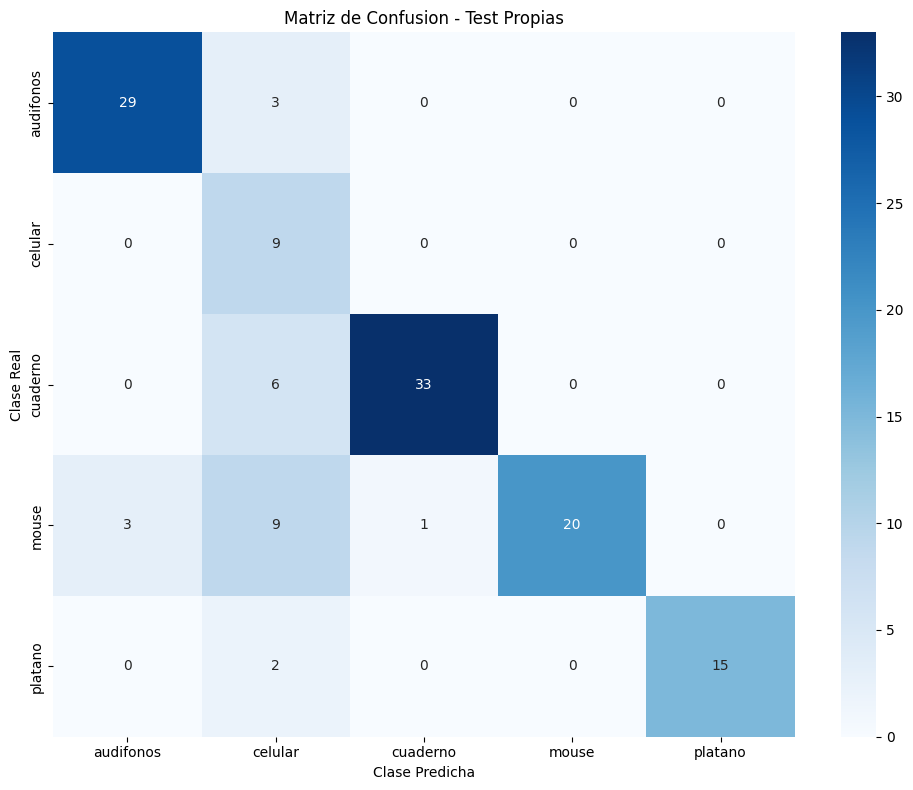


Reporte de clasificacion:
              precision    recall  f1-score   support

   audifonos       0.91      0.91      0.91        32
     celular       0.31      1.00      0.47         9
    cuaderno       0.97      0.85      0.90        39
       mouse       1.00      0.61      0.75        33
     platano       1.00      0.88      0.94        17

    accuracy                           0.82       130
   macro avg       0.84      0.85      0.80       130
weighted avg       0.92      0.82      0.84       130



In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
import numpy as np
import os
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight
from google.colab import files

# 1. Configuración
ruta_dataset = '/content'
categorias = sorted(["celular", "platano", "cuaderno", "mouse", "audifonos"])
img_size = (224, 224)
epochs = 15

# 2. Función para cargar imágenes
def cargar_imagenes(ruta_carpeta):
    X, y = [], []
    for i, categoria in enumerate(categorias):
        ruta_cat = os.path.join(ruta_carpeta, categoria)
        if not os.path.exists(ruta_cat):
            print(f"  Advertencia: no existe {ruta_cat}")
            continue
        archivos = [f for f in os.listdir(ruta_cat) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.jfif', '.bmp'))]
        print(f"  - {categoria}: {len(archivos)} imagenes")
        for archivo in archivos:
            try:
                img = Image.open(os.path.join(ruta_cat, archivo)).convert('RGB').resize(img_size)
                X.append(np.array(img) / 255.0)
                y.append(i)
            except Exception as e:
                print(f"  Error con {archivo}: {e}")
    return np.array(X), np.array(y)

# 3. Cargar datos
print("Cargando dataset...")
print("Train:")
X_train, y_train = cargar_imagenes(os.path.join(ruta_dataset, "train"))
print("Validation:")
X_val, y_val = cargar_imagenes(os.path.join(ruta_dataset, "validation"))
print("Test:")
X_test, y_test = cargar_imagenes(os.path.join(ruta_dataset, "test_propias"))

print(f"\nTotal: Train={X_train.shape[0]}, Val={X_val.shape[0]}, Test={X_test.shape[0]}")

y_train_cat = tf.keras.utils.to_categorical(y_train, len(categorias))
y_val_cat = tf.keras.utils.to_categorical(y_val, len(categorias))
y_test_cat = tf.keras.utils.to_categorical(y_test, len(categorias))

# 4. Calcular pesos de clase para corregir el desbalance
print("\nCalculando pesos de clase para balancear el entrenamiento...")
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))
print("Pesos aplicados:", class_weight_dict)

# 5. Construir modelo
print("\nConstruyendo modelo MobileNetV2...")
base_model = MobileNetV2(input_shape=(*img_size, 3), include_top=False, weights='imagenet')
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(5, activation='softmax')
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# 6. Entrenar con class_weight
print(f"\nEntrenando por {epochs} epochs...")
history = model.fit(X_train, y_train_cat,
                    epochs=epochs,
                    validation_data=(X_val, y_val_cat),
                    class_weight=class_weight_dict,
                    verbose=1)

# 7. Evaluar
print("\nEvaluacion en test (fotos propias):")
test_loss, test_acc = model.evaluate(X_test, y_test_cat)
print(f"Accuracy en test: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"Accuracy en validacion final: {history.history['val_accuracy'][-1]*100:.2f}%")

# 8. Guardar y descargar modelo
model.save('detector_magico.h5')
print("\nDescargando modelo detector_magico.h5...")
files.download('detector_magico.h5')

# 9. Matriz de confusion
print("\nGenerando matriz de confusion...")
predictions = model.predict(X_test)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = y_test

cm = confusion_matrix(true_classes, predicted_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=categorias, yticklabels=categorias)
plt.title('Matriz de Confusion - Test Propias')
plt.ylabel('Clase Real')
plt.xlabel('Clase Predicha')
plt.tight_layout()
plt.savefig('matriz_confusion.png')
plt.show()

print("\nReporte de clasificacion:")
print(classification_report(true_classes, predicted_classes, target_names=categorias))

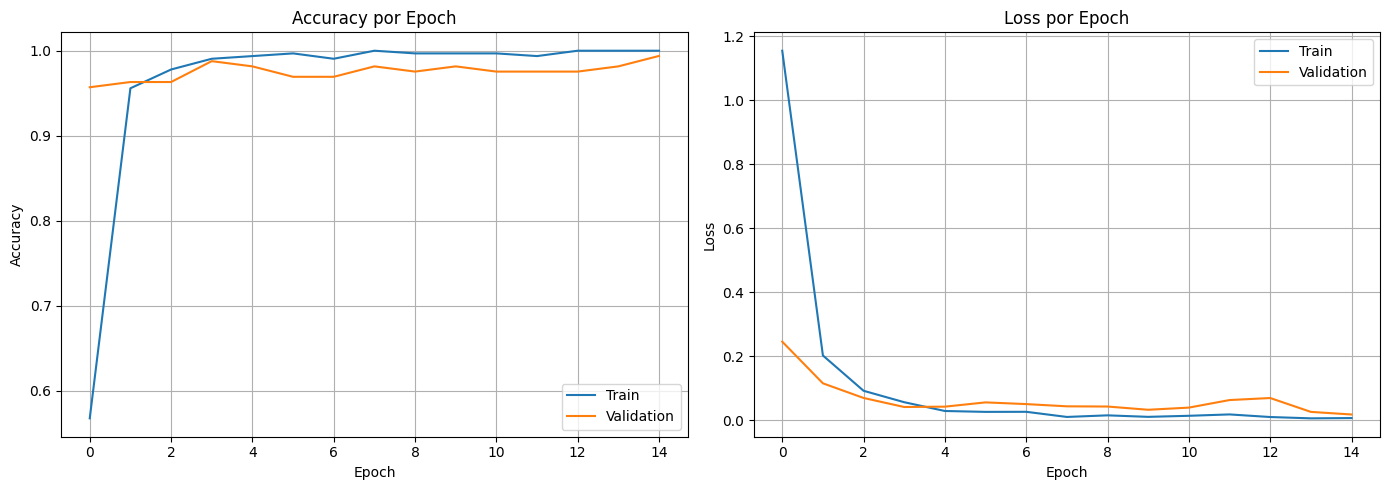

Imagen guardada como 'historial_entrenamiento.png'


In [ ]:
import matplotlib.pyplot as plt

# Verificar si existe el objeto 'history' del entrenamiento
if 'history' in locals():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Gráfica de Accuracy
    ax1.plot(history.history['accuracy'], label='Train')
    ax1.plot(history.history['val_accuracy'], label='Validation')
    ax1.set_title('Accuracy por Epoch')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True)

    # Gráfica de Loss
    ax2.plot(history.history['loss'], label='Train')
    ax2.plot(history.history['val_loss'], label='Validation')
    ax2.set_title('Loss por Epoch')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.savefig('historial_entrenamiento.png')
    plt.show()

    print("Imagen guardada como 'historial_entrenamiento.png'")
else:
    print("ERROR: No se encontró el historial de entrenamiento. Debes ejecutar primero la celda de entrenamiento.")